# Classificação Supervisionada com Fuzzy C-Means no Dataset Adult (Balanceado)

Este notebook apresenta a implementação de um classificador supervisionado baseado no algoritmo Fuzzy C-Means, aplicado ao dataset Adult com balanceamento das classes via oversampling. Todas as etapas são explicadas e o código é comentado para facilitar o entendimento.

## 1. Importação das Bibliotecas

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
import skfuzzy as fuzz
import os
from sklearn.decomposition import PCA

os.makedirs('img', exist_ok=True)

## 2. Carregamento e Balanceamento dos Dados

O dataset Adult é carregado e as classes são balanceadas por oversampling, igualando a quantidade de exemplos das classes. Isso evita que o modelo favoreça a classe majoritária.

In [10]:
adult_df_raw = pd.read_csv('data/AdultDataset/adult.data', header=None, na_values=' ?', skipinitialspace=True)
adult_df_raw.columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]
adult_df_raw['income_bin'] = adult_df_raw['income'].apply(lambda val: 1 if val.strip() == '>50K' else 0)
adult_df_raw = adult_df_raw.dropna()

print('Distribuição original das classes:')
print(adult_df_raw['income_bin'].value_counts())

# Balanceamento por oversampling (ambas as classes terão o mesmo número de exemplos da classe majoritária)
max_count = adult_df_raw['income_bin'].value_counts().max()
adult_df_balanced = pd.DataFrame()
for label in adult_df_raw['income_bin'].unique():
    df_class = adult_df_raw[adult_df_raw['income_bin'] == label]
    df_upsampled = resample(df_class, replace=True, n_samples=max_count, random_state=42)
    adult_df_balanced = pd.concat([adult_df_balanced, df_upsampled])
adult_df_balanced = adult_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print('Distribuição após balanceamento:')
print(adult_df_balanced['income_bin'].value_counts())

Distribuição original das classes:
income_bin
0    24720
1     7841
Name: count, dtype: int64
Distribuição após balanceamento:
income_bin
1    24720
0    24720
Name: count, dtype: int64


## 3. Pré-processamento dos Dados

In [11]:
for col in adult_df_balanced.select_dtypes(include='object').columns:
    if col != 'income':
        adult_df_balanced[col] = LabelEncoder().fit_transform(adult_df_balanced[col].astype(str))
X = adult_df_balanced.drop(['income', 'income_bin'], axis=1).values
y = adult_df_balanced['income_bin'].values
scaler = StandardScaler()
X = scaler.fit_transform(X)

## 4. Divisão dos Dados em Treino e Teste

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

## 5. Definição do Número de Clusters (Método do Cotovelo)

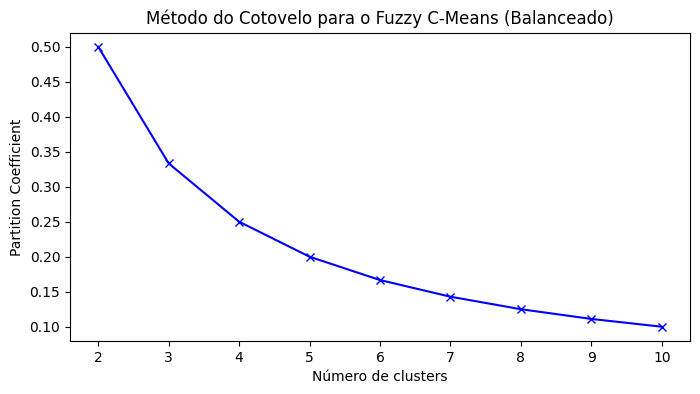

In [13]:
partition_coeffs = []
K = range(2, 11)
for k in K:
    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        X_train.T, c=k, m=2, error=0.005, maxiter=1000, seed=42)
    pc = np.sum(u ** 2) / u.shape[1]
    partition_coeffs.append(pc)

plt.figure(figsize=(8,4))
plt.plot(K, partition_coeffs, 'bx-')
plt.xlabel('Número de clusters')
plt.ylabel('Partition Coefficient')
plt.title('Método do Cotovelo para o Fuzzy C-Means (Balanceado)')
plt.savefig('img/cmeans_adult_balance_elbow.png')
plt.show()

## 6. Implementação do Classificador Fuzzy C-Means Supervisionado

In [14]:
class FuzzyCMeansSupervisionado:
    def __init__(self, n_clusters=2, m=2, random_state=0):
        self.n_clusters = n_clusters
        self.m = m
        self.random_state = random_state
        self.centers_ = None
        self.cluster_labels_ = None

    def fit(self, X, y):
        cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
            X.T, c=self.n_clusters, m=self.m, error=0.005, maxiter=1000, seed=self.random_state)
        self.centers_ = cntr
        labels = np.argmax(u, axis=0)
        self.cluster_labels_ = []
        for i in range(self.n_clusters):
            mask = (labels == i)
            if np.any(mask):
                label = np.bincount(y[mask]).argmax()
            else:
                label = -1
            self.cluster_labels_.append(label)

    def predict(self, X):
        u, _, _, _, _, _ = fuzz.cluster.cmeans_predict(
            X.T, self.centers_, m=self.m, error=0.005, maxiter=1000)
        clusters = np.argmax(u, axis=0)
        return np.array([self.cluster_labels_[c] for c in clusters])

    def evaluate(self, X, y_true):
        y_pred = self.predict(X)
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        return acc, cm

## 7. Treinamento e Avaliação do Classificador

Acurácia: 0.7186
Matriz de Confusão:
[[4567 2849]
 [1324 6092]]


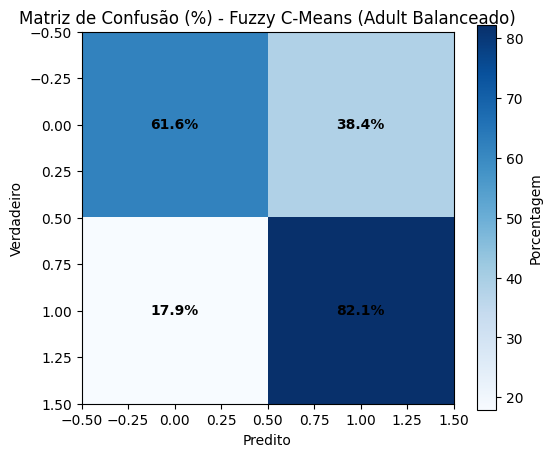

In [15]:
n_clusters = 8  # Ajuste conforme o gráfico do cotovelo

clf = FuzzyCMeansSupervisionado(n_clusters=n_clusters, random_state=42)
clf.fit(X_train, y_train)

acc, cm = clf.evaluate(X_test, y_test)
print(f'Acurácia: {acc:.4f}')
print('Matriz de Confusão:')
print(cm)

plt.figure(figsize=(6,5))
cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100
plt.imshow(cm_percent, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão (%) - Fuzzy C-Means (Adult Balanceado)')
plt.colorbar(label='Porcentagem')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
for i in range(cm_percent.shape[0]):
    for j in range(cm_percent.shape[1]):
        plt.text(j, i, f'{cm_percent[i, j]:.1f}%', ha='center', va='center', color='black', fontsize=10, fontweight='bold')
plt.savefig('img/cmeans_adult_balance_confusion_matrix.png')
plt.show()

## 8. Repetição dos Experimentos e Métricas

Acurácia média: 0.7259
Desvio padrão da acurácia: 0.0034
Matriz de confusão média (percentual):
[[63.1 36.9]
 [17.9 82.1]]


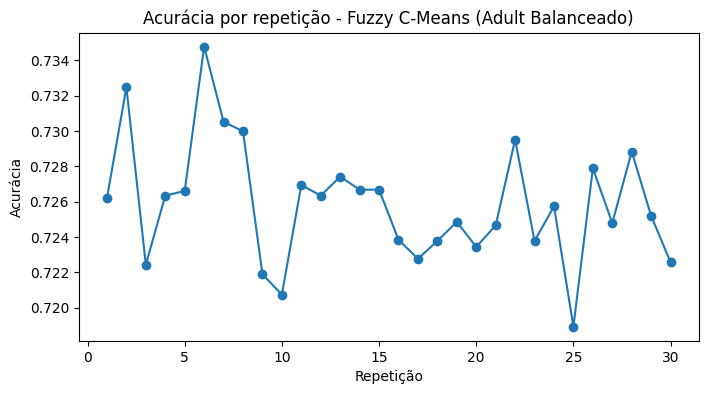

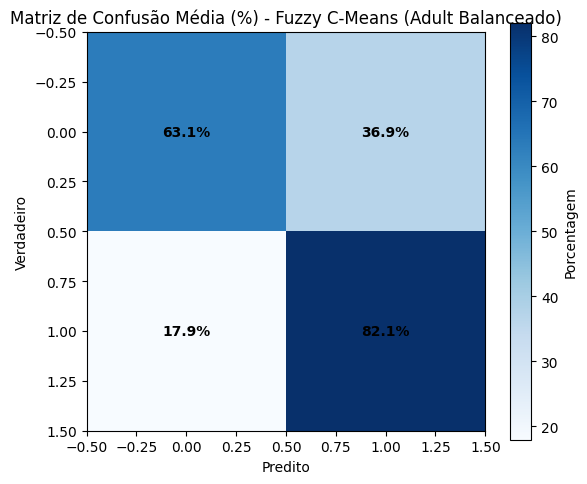

In [16]:
acuracias = []
matrizes_confusao = []
from sklearn.metrics import mean_squared_error, confusion_matrix
classes = np.unique(y)
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = FuzzyCMeansSupervisionado(n_clusters=n_clusters, random_state=seed)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    acuracias.append(acc)
    matrizes_confusao.append(confusion_matrix(y_test, y_pred, labels=classes))

acuracias = np.array(acuracias)
matrizes_confusao = np.array(matrizes_confusao)
matriz_confusao_media = np.mean(matrizes_confusao, axis=0)
matriz_confusao_media_percent = matriz_confusao_media / matriz_confusao_media.sum(axis=1, keepdims=True) * 100

print(f'Acurácia média: {acuracias.mean():.4f}')
print(f'Desvio padrão da acurácia: {acuracias.std():.4f}')
print("Matriz de confusão média (percentual):")
print(np.round(matriz_confusao_media_percent, 1))

plt.figure(figsize=(8,4))
plt.plot(range(1,31), acuracias, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Acurácia')
plt.title('Acurácia por repetição - Fuzzy C-Means (Adult Balanceado)')
plt.savefig('img/cmeans_adult_balance_accuracy_repetitions.png')
plt.show()

plt.figure(figsize=(6,5))
plt.imshow(matriz_confusao_media_percent, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão Média (%) - Fuzzy C-Means (Adult Balanceado)')
plt.colorbar(label='Porcentagem')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
for i in range(matriz_confusao_media_percent.shape[0]):
    for j in range(matriz_confusao_media_percent.shape[1]):
        plt.text(j, i, f'{matriz_confusao_media_percent[i, j]:.1f}%', ha='center', va='center', color='black', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('img/cmeans_adult_balance_confusion_matrix_media_percent.png')
plt.show()

# Salvar resultados para análise posterior
np.save('img/cmeans_adult_balance_accuracies.npy', acuracias)
np.savetxt('img/cmeans_adult_balance_accuracies.csv', acuracias, delimiter=',')
np.save('img/cmeans_adult_balance_confusion_matrix_media_percent.npy', matriz_confusao_media_percent)
np.savetxt('img/cmeans_adult_balance_confusion_matrix_media_percent.csv', matriz_confusao_media_percent, delimiter=',')

## 9. Visualização dos Clusters e Centros (PCA)

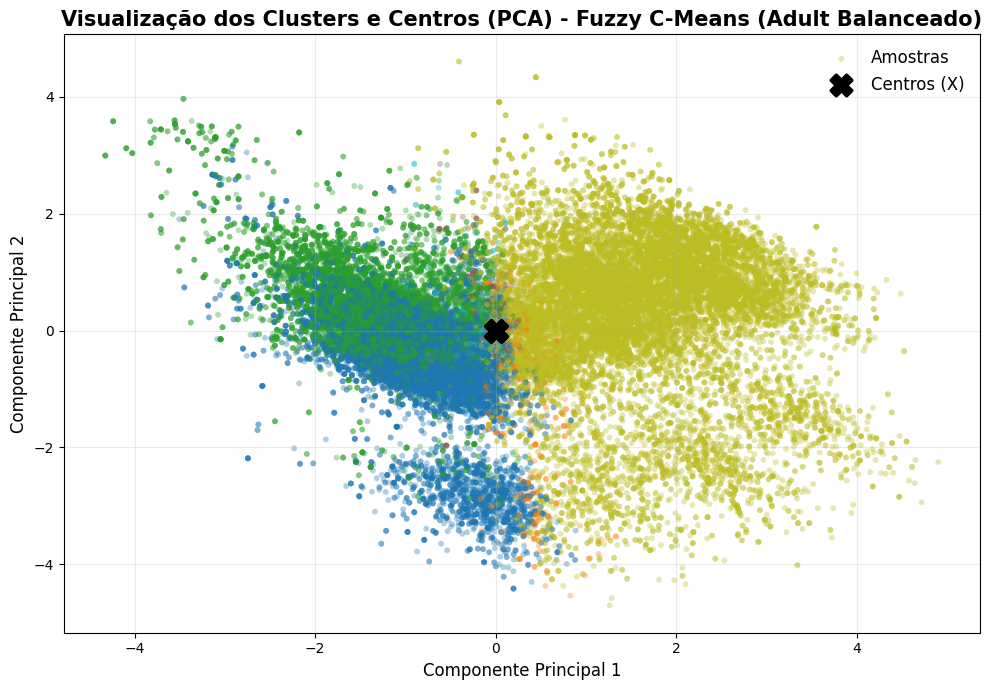

In [17]:
# Redução de dimensionalidade para 2D com PCA (antes do clustering)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Executa o Fuzzy C-Means para obter os clusters e centros
clf = FuzzyCMeansSupervisionado(n_clusters=8, random_state=42)
clf.fit(X, y)
u, _, _, _, _, _ = fuzz.cluster.cmeans_predict(X.T, clf.centers_, m=2, error=0.005, maxiter=1000)
clusters = np.argmax(u, axis=0)
centros_pca = pca.transform(clf.centers_)

# Gráfico 2D dos clusters e centros (X em preto)
plt.figure(figsize=(10,7))
plt.scatter(
    X_pca[:,0], X_pca[:,1], 
    c=clusters, cmap='tab10', alpha=0.35, s=18, edgecolor='none', label='Amostras'
)
plt.scatter(
    centros_pca[:,0], centros_pca[:,1], 
    c='black', marker='X', s=220, linewidths=2.5, zorder=4, label='Centros (X)'
)
plt.title('Visualização dos Clusters e Centros (PCA) - Fuzzy C-Means (Adult Balanceado)', fontsize=15, fontweight='bold')
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.grid(alpha=0.25)
plt.legend(frameon=False, fontsize=12, loc='best')
plt.tight_layout()
plt.savefig('img/cmeans_adult_balance_clusters_pca.png', dpi=150)
plt.show()

## 10. Análise Crítica dos Resultados e Métricas

Nesta etapa, analisamos criticamente os resultados obtidos pelo classificador Fuzzy C-Means no dataset Adult balanceado. As principais métricas reportadas são a acurácia média e o desvio padrão, que avaliam o desempenho global e a estabilidade do modelo frente a diferentes divisões dos dados. A visualização dos clusters e centros via PCA permite interpretar a separação dos grupos no espaço de atributos.

- **Acurácia média e desvio padrão:** Avaliam o desempenho global e a estabilidade do modelo.
- **Visualização dos clusters:** Permite analisar a separação dos grupos e possíveis sobreposições.

**Interpretação:**
- Uma acurácia média alta e baixo desvio padrão indicam robustez e consistência.
- A visualização dos clusters pode revelar padrões ou limitações do agrupamento.

**Sugestões:**
- Compare os resultados do Fuzzy C-Means com outros métodos (KMeans, Agglomerative, GK) para avaliar qual abordagem é mais adequada ao problema.
- Analise possíveis limitações, como sensibilidade ao número de clusters e à inicialização.
- Considere ajustes no pré-processamento ou no balanceamento para melhorar o desempenho.

Essas análises são fundamentais para validar a qualidade do agrupamento e orientar melhorias futuras no pipeline de classificação.

## 11. Inspeção dos Centros do Fuzzy C-Means

Nesta seção, inspecionamos os centros encontrados pelo Fuzzy C-Means, exibindo suas coordenadas nas primeiras três dimensões e as distâncias entre eles. Além disso, uma visualização em 3D dos centros e amostras é apresentada, facilitando a análise de sobreposição ou colapso dos centros.

- **Centros encontrados: ** Coordenadas dos centros das classes identificadas.
- **Distâncias entre os centros:** Avalia a separação entre os diferentes clusters.

A análise das distâncias entre os centros e sua visualização em 3D são úteis para entender a distribuição e separação dos clusters no espaço de atributos.

Centros encontrados (primeiras 3 dimensões):
[[ 2.07888136e-04  6.69002260e-05 -4.68397383e-05]
 [ 9.47257216e-05  1.38775202e-05 -1.62422053e-05]
 [ 1.85293467e-04  8.48764161e-05 -5.54367602e-05]
 [ 2.08357266e-05  5.73162337e-06 -1.54957979e-06]
 [-1.11469373e-04 -3.03943423e-05  2.82199794e-05]
 [-1.46737239e-04 -5.59432361e-05  3.23180818e-05]
 [-2.26875938e-04 -9.04432055e-05  5.28056742e-05]
 [-2.37717955e-05  5.37984447e-06  6.70955619e-06]]
Distâncias entre os centros:
[[0.         0.00041588 0.00011464 0.0006183  0.00102051 0.00118891
  0.00146712 0.00072909]
 [0.00041588 0.         0.00040061 0.00021117 0.0006108  0.00077563
  0.0010526  0.00033043]
 [0.00011464 0.00040061 0.         0.0005848  0.00098183 0.00115377
  0.00143375 0.00068625]
 [0.0006183  0.00021117 0.0005848  0.         0.00040251 0.00057125
  0.00085045 0.00012142]
 [0.00102051 0.0006108  0.00098183 0.00040251 0.         0.00017528
  0.00045422 0.00029605]
 [0.00118891 0.00077563 0.00115377 0.00057125 0.0001

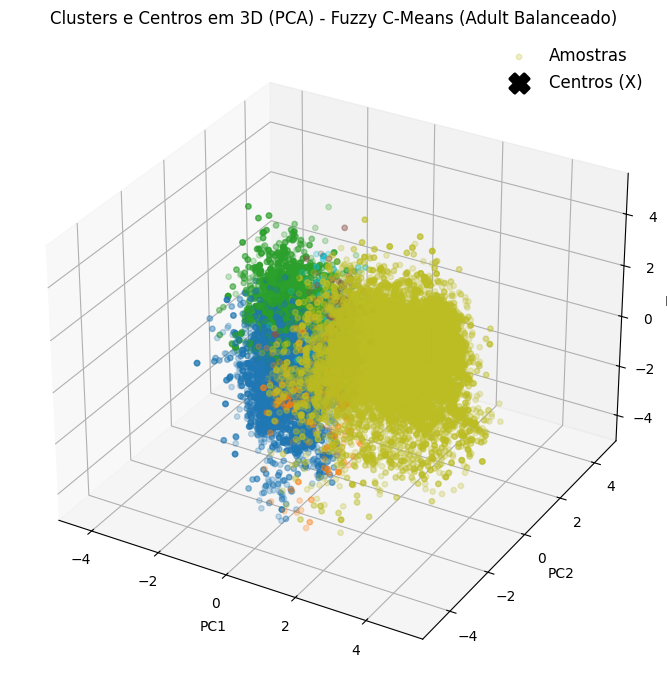

In [18]:
# Inspecionando os centros encontrados pelo Fuzzy C-Means
print('Centros encontrados (primeiras 3 dimensões):')
print(clf.centers_[:, :3])
print('Distâncias entre os centros:')
from scipy.spatial.distance import pdist, squareform
print(squareform(pdist(clf.centers_)))

# Visualização em 3D dos centros e amostras
from mpl_toolkits.mplot3d import Axes3D
pca3d = PCA(n_components=3)
X_pca3d = pca3d.fit_transform(X)
centros_pca3d = pca3d.transform(clf.centers_)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca3d[:,0], X_pca3d[:,1], X_pca3d[:,2], c=clusters, cmap='tab10', alpha=0.25, s=15, label='Amostras')
ax.scatter(centros_pca3d[:,0], centros_pca3d[:,1], centros_pca3d[:,2], c='black', marker='X', s=180, linewidths=2.5, label='Centros (X)')
ax.set_title('Clusters e Centros em 3D (PCA) - Fuzzy C-Means (Adult Balanceado)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.legend(frameon=False, fontsize=12, loc='best')
plt.tight_layout()
plt.show()

## Teste com n_clusters=2 para o Adult

Centros encontrados (n_clusters=2, primeiras 3 dimensões):
[[ 7.48166568e-05  3.07148483e-05 -1.85090931e-05]
 [-7.48243284e-05 -3.07161338e-05  1.85080705e-05]]
Distância entre os centros:
[0.00052332]


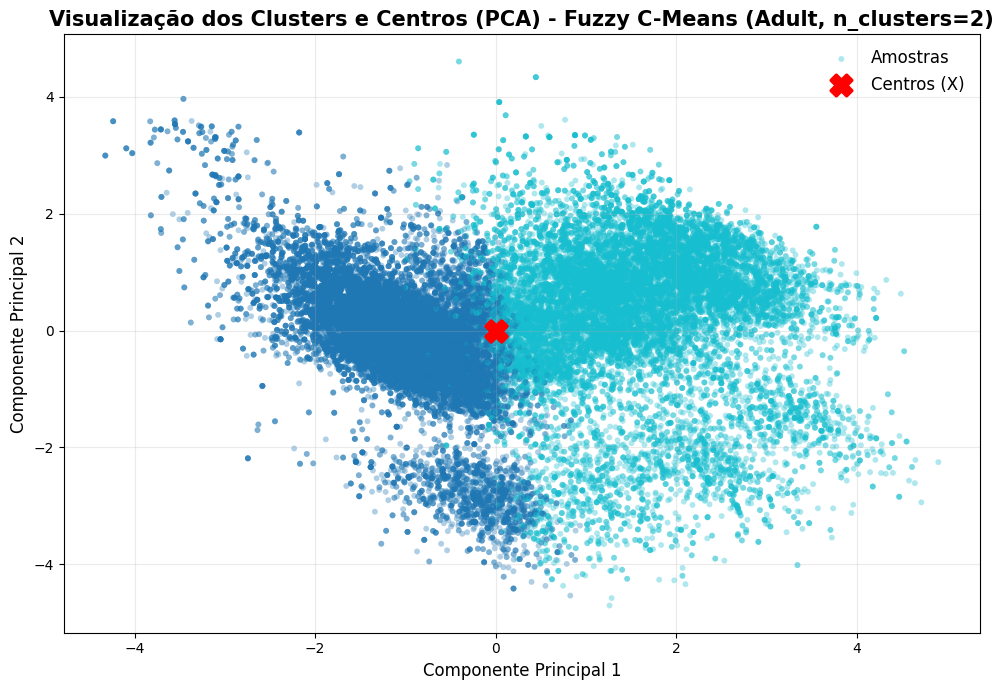

In [19]:
n_clusters_teste = 2
clf2 = FuzzyCMeansSupervisionado(n_clusters=n_clusters_teste, random_state=42)
clf2.fit(X, y)
u2, _, _, _, _, _ = fuzz.cluster.cmeans_predict(X.T, clf2.centers_, m=2, error=0.005, maxiter=1000)
clusters2 = np.argmax(u2, axis=0)
centros_pca2 = pca.transform(clf2.centers_)

print('Centros encontrados (n_clusters=2, primeiras 3 dimensões):')
print(clf2.centers_[:, :3])
print('Distância entre os centros:')
from scipy.spatial.distance import pdist
print(pdist(clf2.centers_))

plt.figure(figsize=(10,7))
plt.scatter(
    X_pca[:,0], X_pca[:,1], 
    c=clusters2, cmap='tab10', alpha=0.35, s=18, edgecolor='none', label='Amostras')
plt.scatter(
    centros_pca2[:,0], centros_pca2[:,1], 
    c='red', marker='X', s=220, linewidths=2.5, zorder=4, label='Centros (X)')
plt.title('Visualização dos Clusters e Centros (PCA) - Fuzzy C-Means (Adult, n_clusters=2)', fontsize=15, fontweight='bold')
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.grid(alpha=0.25)
plt.legend(frameon=False, fontsize=12, loc='best')
plt.tight_layout()
plt.show()